In [1]:
import networkx as nx
import numpy as np
from scipy.io import mmread
import pandas as pd
import matplotlib.cm as cmx
import matplotlib.colors as colors

from sklearn import metrics
import matplotlib.pyplot as plt
import copy
import scipy.sparse as sp
import scanpy as sc
import os
import anndata as ad
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
gene_TCR = ad.read_h5ad('./10Xdatasets/gex_merge_log1_5000_genes_all_peptides.h5ad')
gene_TCR.obs['used_ix'] = range(gene_TCR.shape[0])
donor_1234 = gene_TCR[gene_TCR.obs['donor'] != 'donor3']
donor_1234

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


View of AnnData object with n_obs × n_vars = 115245 × 5000
    obs: 'v_gene_TRA', 'v_gene_TRB', 'd_gene_TRA', 'd_gene_TRB', 'j_gene_TRA', 'j_gene_TRB', 'c_gene_TRA', 'c_gene_TRB', 'cdr3_TRA', 'cdr3_TRB', 'cdr3_nt_TRA', 'cdr3_nt_TRB', 'umis_TRA', 'umis_TRB', 'donor', 'cell_clono_cdr3_aa', 'cell_clono_cdr3_nt', 'CD3', 'CD19', 'CD45RA', 'CD4', 'CD8a', 'CD14', 'CD45RO', 'CD279_PD-1', 'IgG1', 'IgG2a', 'IgG2b', 'CD127', 'CD197_CCR7', 'HLA-DR', 'A0101_VTEHDTLLY_IE-1_CMV', 'A0201_KTWGQYWQV_gp100_Cancer', 'A0201_ELAGIGILTV_MART-1_Cancer', 'A0201_CLLWSFQTSA_Tyrosinase_Cancer', 'A0201_IMDQVPFSV_gp100_Cancer', 'A0201_SLLMWITQV_NY-ESO-1_Cancer', 'A0201_KVAELVHFL_MAGE-A3_Cancer', 'A0201_KVLEYVIKV_MAGE-A1_Cancer', 'A0201_CLLGTYTQDV_Kanamycin-B-dioxygenase', 'A0201_LLDFVRFMGV_EBNA-3B_EBV', 'A0201_LLMGTLGIVC_HPV-16E7_82-91', 'A0201_CLGGLLTMV_LMP-2A_EBV', 'A0201_YLLEMLWRL_LMP1_EBV', 'A0201_FLYALALLL_LMP2A_EBV', 'A0201_GILGFVFTL_Flu-MP_Influenza', 'A0201_GLCTLVAML_BMLF1_EBV', 'A0201_NLVPMVATV_pp65_CMV', 

In [3]:
data_10X_dat = donor_1234.obs
data_10X_dat

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,B0702_GPAESAAGL_NC,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix
barcode,,,,,,,,,,,,,,,,,,,,,
AGGGTGAGTATTACCG-18,TRAV19,TRBV20-1,None,TRBD2,TRAJ40,TRBJ2-3,TRAC,TRBC2,CALSEASGTYKYIF,CSAPSGEGRDTQYF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,0,5478.0,3.738622,1830,0.058050,0
CTTGGCTTCGTTGCCT-25,TRAV23DV6,TRBV7-2,None,TRBD1,TRAJ48,TRBJ2-5,TRAC,TRBC2,CAAILFGNEKLTF,CASSLFDSQETQYF,...,0.0,0.0,unknown,nan,1,4585.0,3.661339,1382,0.063250,1
ACGATACTCGCAGGCT-40,TRAV9-2,TRBV7-6,None,TRBD2,TRAJ49,TRBJ2-3,TRAC,TRBC2,CALSADTGNQFYF,CASSLFDSGRLDTQYF,...,0.0,0.0,unknown,nan,2,3742.0,3.573104,1279,0.067611,2
ACGCCAGTCATGTCTT-8,TRAV12-3,TRBV20-1,None,TRBD1,TRAJ32,TRBJ2-7,TRAC,TRBC2,CAMNPAWGGATNKLIF,CSASPGDYEQYF,...,0.0,0.0,unknown,nan,4,4368.0,3.640283,1669,0.054716,3
TTCTTAGCAAAGAATC-4,TRAV13-2,TRBV4-1,None,TRBD2,TRAJ37,TRBJ2-1,TRAC,TRBC2,CAETALGNTGKLIF,CASSHGKGGNEQFF,...,0.0,0.0,unknown,nan,5,9129.0,3.960423,2683,0.044035,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GAAGCAGAGCAGGCTA-3,TRAV22,TRBV24-1,None,TRBD2,TRAJ47,TRBJ2-2,TRAC,TRBC2,CAVEPLYGNKLVF,CATSDRLAGGELFF,...,0.0,0.0,unknown,nan,159412,1547.0,3.189490,789,0.135747,145474
CAGTCCTTCATCACCC-8,TRAV29DV5,TRBV7-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAATHASGYDKVIF,CASSYLAGDFTDTQYF,...,0.0,0.0,unknown,nan,159414,3934.0,3.594834,1468,0.041688,145475
GACTACACACGGTAAG-3,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159415,4267.0,3.630123,1646,0.047574,145476


In [4]:
from sklearn.decomposition import NMF

In [5]:
# model_nmf = NMF(n_components=100, init='random', random_state=0)
# model_nmf.fit(donor_4.X)

In [6]:
# W = model_nmf.transform(donor_4.X)
# H = model_nmf.components_

In [7]:
# W_df = pd.DataFrame(W)

In [8]:
# W_df

In [9]:
# all_embeddings_df = pd.read_csv('./data_10X_full_data_emb_dat_mvTCR_clean_PCAs_041.csv')
all_embeddings_df_alpha_chain = pd.read_csv('./minervina/integration_pred_new_method_gex_to_TCR_alpha_chain_10X_donor_4_only.csv')
all_embeddings_df_beta_chain = pd.read_csv('./minervina/integration_pred_new_method_gex_to_TCR_beta_chain_10X_all_peptides_64.csv')


In [10]:
all_embeddings_df_beta_chain

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.000000,0.0,0.000000,0.000000,0.000000,0.0000,47.228542,0.0,0.000000,0.000000,...,0.0,0.0,68.318830,33.565807,9.623429,0.000000,0.000000,0.0,2.760498,0.0
1,47.789253,0.0,102.993965,15.535086,61.720900,0.0000,25.429663,0.0,74.778880,58.308903,...,0.0,0.0,45.327060,45.413150,1.543865,69.383400,121.986540,0.0,0.000000,0.0
2,11.189564,0.0,0.000000,0.000000,58.052720,0.0000,34.022545,0.0,54.010426,38.685490,...,0.0,0.0,71.304250,71.958405,63.148613,23.200869,71.336210,0.0,15.889585,0.0
3,31.903708,0.0,0.000000,0.000000,0.000000,40.5308,68.250946,0.0,0.000000,11.678909,...,0.0,0.0,52.853497,42.781210,96.442820,0.000000,0.000000,0.0,12.678916,0.0
4,64.095180,0.0,7.637758,0.000000,32.763380,0.0000,60.871044,0.0,88.323135,60.249767,...,0.0,0.0,53.772038,39.190520,2.420441,91.297420,25.990637,0.0,40.994488,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145474,10.692663,0.0,0.000000,16.909035,26.930958,0.0000,9.929898,0.0,0.000000,0.000000,...,0.0,0.0,71.743860,37.790455,0.000000,0.000000,16.106989,0.0,43.563000,0.0
145475,0.000000,0.0,0.000000,0.000000,74.438140,0.0000,71.923410,0.0,33.537617,69.157890,...,0.0,0.0,61.490240,73.279854,49.702354,25.620972,46.547188,0.0,10.342027,0.0
145476,32.137140,0.0,38.408530,0.000000,57.234300,0.0000,32.369823,0.0,7.119116,0.000000,...,0.0,0.0,66.454910,0.000000,68.053560,0.000000,0.000000,0.0,32.030697,0.0
145477,37.856102,0.0,0.000000,19.094307,46.111496,0.0000,31.544832,0.0,39.797424,34.629640,...,0.0,0.0,43.814594,57.811210,51.896137,22.175943,59.529040,0.0,21.128685,0.0


In [25]:

# all_embed = pd.concat([all_embeddings_df_alpha_chain,all_embeddings_df_beta_chain, W_df], axis=1)
# all_embed = pd.concat([all_embeddings_df_alpha_chain,all_embeddings_df_beta_chain], axis=1)
all_embed = all_embeddings_df_beta_chain.iloc[donor_1234.obs['used_ix'], :]
all_embed

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.000000,0.0,0.000000,0.000000,0.000000,0.0000,47.228542,0.0,0.000000,0.000000,...,0.0,0.0,68.318830,33.565807,9.623429,0.000000,0.000000,0.0,2.760498,0.0
1,47.789253,0.0,102.993965,15.535086,61.720900,0.0000,25.429663,0.0,74.778880,58.308903,...,0.0,0.0,45.327060,45.413150,1.543865,69.383400,121.986540,0.0,0.000000,0.0
2,11.189564,0.0,0.000000,0.000000,58.052720,0.0000,34.022545,0.0,54.010426,38.685490,...,0.0,0.0,71.304250,71.958405,63.148613,23.200869,71.336210,0.0,15.889585,0.0
3,31.903708,0.0,0.000000,0.000000,0.000000,40.5308,68.250946,0.0,0.000000,11.678909,...,0.0,0.0,52.853497,42.781210,96.442820,0.000000,0.000000,0.0,12.678916,0.0
4,64.095180,0.0,7.637758,0.000000,32.763380,0.0000,60.871044,0.0,88.323135,60.249767,...,0.0,0.0,53.772038,39.190520,2.420441,91.297420,25.990637,0.0,40.994488,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145474,10.692663,0.0,0.000000,16.909035,26.930958,0.0000,9.929898,0.0,0.000000,0.000000,...,0.0,0.0,71.743860,37.790455,0.000000,0.000000,16.106989,0.0,43.563000,0.0
145475,0.000000,0.0,0.000000,0.000000,74.438140,0.0000,71.923410,0.0,33.537617,69.157890,...,0.0,0.0,61.490240,73.279854,49.702354,25.620972,46.547188,0.0,10.342027,0.0
145476,32.137140,0.0,38.408530,0.000000,57.234300,0.0000,32.369823,0.0,7.119116,0.000000,...,0.0,0.0,66.454910,0.000000,68.053560,0.000000,0.000000,0.0,32.030697,0.0
145477,37.856102,0.0,0.000000,19.094307,46.111496,0.0000,31.544832,0.0,39.797424,34.629640,...,0.0,0.0,43.814594,57.811210,51.896137,22.175943,59.529040,0.0,21.128685,0.0


In [12]:
import anndata as ad

In [13]:
donor_1_peptides = ['A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'B0801_RAKFKQLL_BZLF1_EBV_binder',            
         'A0201_GLCTLVAML_BMLF1_EBV_binder']           
donor_2_peptides = ['B0801_RAKFKQLL_BZLF1_EBV_binder',            
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A0201_GLCTLVAML_BMLF1_EBV_binder',          
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder']      
donor_3_peptides = ['A0301_KLGGALQAK_IE-1_CMV_binder',           
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'B0801_RAKFKQLL_BZLF1_EBV_binder']            
donor_4_peptides = ['A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',       
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A0201_GLCTLVAML_BMLF1_EBV_binder']           

In [14]:
donor_all_peptides = list(set(donor_1_peptides + donor_2_peptides + donor_3_peptides + donor_4_peptides))
donor_all_peptides

['A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder']

In [ ]:
['unknown',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_FLYALALLL_LMP2A_EBV_binder']

In [15]:
top16_peptide = data_10X_dat.antigen.value_counts().index.to_list()
top16_peptide

['unknown',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_FLYALALLL_LMP2A_EBV_binder',
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder',
 'B0801_FLRGRAYGL_EBNA-3A_EBV_binder',
 'A0201_LLFGYPVYV_HTLV-1_binder',
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder',
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder',
 'A2402_AYAQKIFKI_IE-1_CMV_binder',
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder',
 'A0201_YLLEMLWRL_LMP1_EBV_binder',
 'A2402_QYDPVAALF_pp65_CMV_binder',
 'A2402_CYTWNQMNL_WT1-(235-243)236M_Y_binder',
 'A0201_IMDQVPFSV_gp100_Cancer_binder',
 'A0201_MLDLQPETT_16E7_HPV_binder',
 'A0201_KTWGQYWQV_gp100_Cancer_binder',
 'A0201_YLNDHLEPWI_BCL-X_Cancer_binder',
 'A0201_KVLEYVIKV_MAGE-A1_Cancer_binder',
 'A0201_RMFPNAPYL_WT-1_binder',
 'B3

In [16]:
data_10X_dat.columns

Index(['v_gene_TRA', 'v_gene_TRB', 'd_gene_TRA', 'd_gene_TRB', 'j_gene_TRA',
       'j_gene_TRB', 'c_gene_TRA', 'c_gene_TRB', 'cdr3_TRA', 'cdr3_TRB',
       'cdr3_nt_TRA', 'cdr3_nt_TRB', 'umis_TRA', 'umis_TRB', 'donor',
       'cell_clono_cdr3_aa', 'cell_clono_cdr3_nt', 'CD3', 'CD19', 'CD45RA',
       'CD4', 'CD8a', 'CD14', 'CD45RO', 'CD279_PD-1', 'IgG1', 'IgG2a', 'IgG2b',
       'CD127', 'CD197_CCR7', 'HLA-DR', 'A0101_VTEHDTLLY_IE-1_CMV',
       'A0201_KTWGQYWQV_gp100_Cancer', 'A0201_ELAGIGILTV_MART-1_Cancer',
       'A0201_CLLWSFQTSA_Tyrosinase_Cancer', 'A0201_IMDQVPFSV_gp100_Cancer',
       'A0201_SLLMWITQV_NY-ESO-1_Cancer', 'A0201_KVAELVHFL_MAGE-A3_Cancer',
       'A0201_KVLEYVIKV_MAGE-A1_Cancer',
       'A0201_CLLGTYTQDV_Kanamycin-B-dioxygenase',
       'A0201_LLDFVRFMGV_EBNA-3B_EBV', 'A0201_LLMGTLGIVC_HPV-16E7_82-91',
       'A0201_CLGGLLTMV_LMP-2A_EBV', 'A0201_YLLEMLWRL_LMP1_EBV',
       'A0201_FLYALALLL_LMP2A_EBV', 'A0201_GILGFVFTL_Flu-MP_Influenza',
       'A0201_GLCTLVAML_BML

In [17]:
top16_peptide[1:10]

['B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_FLYALALLL_LMP2A_EBV_binder']

In [18]:
bind_list = top16_peptide[1:10]
bind_list.append('unknown')
bind_list

['B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_FLYALALLL_LMP2A_EBV_binder',
 'unknown']

In [19]:
from distinctipy import distinctipy

colors_distinct = distinctipy.get_colors(len(bind_list)-1)


In [20]:
colors_distinct.append((0.75,0.75,0.75))
colors_distinct

[(0.0, 1.0, 0.0),
 (1.0, 0.0, 1.0),
 (0.0, 0.5, 1.0),
 (1.0, 0.5, 0.0),
 (0.5, 0.75, 0.5),
 (0.5800349387286523, 0.13869245992389279, 0.42064663508587874),
 (0.2399318876392048, 0.5012097931679649, 0.004829381854747905),
 (0.017693052069077453, 0.00010496879648880242, 0.8618050804075605),
 (0.0, 1.0, 1.0),
 (0.75, 0.75, 0.75)]

In [21]:
antigen_colors = dict(map(lambda i,j : (i,j) , bind_list,colors_distinct))
antigen_colors

{'B0801_RAKFKQLL_BZLF1_EBV_binder': (0.0, 1.0, 0.0),
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder': (1.0, 0.0, 1.0),
 'A0301_KLGGALQAK_IE-1_CMV_binder': (0.0, 0.5, 1.0),
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (1.0, 0.5, 0.0),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (0.5, 0.75, 0.5),
 'A0201_GLCTLVAML_BMLF1_EBV_binder': (0.5800349387286523,
  0.13869245992389279,
  0.42064663508587874),
 'A0201_ELAGIGILTV_MART-1_Cancer_binder': (0.2399318876392048,
  0.5012097931679649,
  0.004829381854747905),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.017693052069077453,
  0.00010496879648880242,
  0.8618050804075605),
 'A0201_FLYALALLL_LMP2A_EBV_binder': (0.0, 1.0, 1.0),
 'unknown': (0.75, 0.75, 0.75)}

In [22]:
top16_peptide[1:10]

['B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_FLYALALLL_LMP2A_EBV_binder']

In [23]:

from sklearn.metrics.cluster import normalized_mutual_info_score
from tqdm import tqdm
adata_gene = donor_1234
adata_gene.obs = data_10X_dat
adata_gene = adata_gene[adata_gene.obs.antigen.isin(donor_all_peptides)]
# sc.pp.normalize_total(adata_gene, target_sum=1e4)
sc.tl.pca(adata_gene,svd_solver='arpack')
best_nmi = 0
best_resolution = 0
best_n_neighbors = 0
for npcs in tqdm([25, 30,35]):
    for resolution in [ 0.3, 0.4, 0.5, 0.6, 0.7]:
        for n_neighbors in [5, 10, 15, 20, 25, 30]:
            sc.pp.neighbors(adata_gene, n_neighbors=n_neighbors, n_pcs=npcs)
            sc.tl.leiden(adata_gene, resolution=resolution)
            nmi_score = normalized_mutual_info_score(
                adata_gene.obs['leiden'].astype('int').values,
                adata_gene.obs['peptide'].astype('category').cat.codes.values
            )
            print(f"Resolution: {resolution}, N_neighbors: {n_neighbors}, NMI Score: {nmi_score}, PCs: {npcs}")
            if nmi_score > best_nmi:
                best_nmi = nmi_score
                best_resolution = resolution
                best_n_neighbors = n_neighbors
                best_npcs = npcs
print(f"Best NMI Score: {best_nmi} at Resolution: {best_resolution}, N_neighbors: {best_n_neighbors}, PCs: {best_npcs}")

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:796: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
  0%|          | 0/3 [00:00<?, ?it/s]2026-03-03 14:46

Resolution: 0.3, N_neighbors: 5, NMI Score: 0.358927243206925, PCs: 25
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.3538230190787631, PCs: 25
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.3514666786171244, PCs: 25
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.3504329622920605, PCs: 25
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.34541298913374235, PCs: 25
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.35113553287602967, PCs: 25
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.3454997180497931, PCs: 25
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.3492385075639333, PCs: 25
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.3535361203845149, PCs: 25
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.35892405188376714, PCs: 25
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.36097041734697144, PCs: 25
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.360819781392471, PCs: 25
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.34241039650857974, PCs: 25
Resolution: 0.5, N_neighbors: 10, NMI Score: 0.3579

 33%|███▎      | 1/3 [23:14<46:28, 1394.37s/it]

Resolution: 0.7, N_neighbors: 30, NMI Score: 0.3493922628597755, PCs: 25
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.3463284109435419, PCs: 30
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.35972862144810747, PCs: 30
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.3510142497493054, PCs: 30
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.35715151517967475, PCs: 30
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.3497485144957327, PCs: 30
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.3504434685698761, PCs: 30
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.3642030621164819, PCs: 30
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.3454848617431815, PCs: 30
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.3560762024506301, PCs: 30
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.35753546593797064, PCs: 30
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.3597638868863207, PCs: 30
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.3554739177020626, PCs: 30
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.3412

 33%|███▎      | 1/3 [31:28<1:02:57, 1888.54s/it]


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics.cluster import adjusted_rand_score

In [ ]:
from sklearn.metrics.cluster import normalized_mutual_info_score
from tqdm import tqdm
adata_gene = donor_1234
adata_gene.obs = data_10X_dat
adata_gene = adata_gene[adata_gene.obs.antigen.isin(donor_all_peptides)]
# sc.pp.normalize_total(adata_gene, target_sum=1e4)
sc.tl.pca(adata_gene,svd_solver='arpack')
sc.pp.neighbors(adata_gene, n_neighbors=best_n_neighbors, n_pcs=best_npcs)
# sc.pp.neighbors(adata_gene, n_neighbors=10, n_pcs=35)
sc.tl.leiden(adata_gene, resolution=0.3)
normalized_mutual_info_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )
adjusted_rand_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

In [ ]:
normalized_mutual_info_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

In [ ]:
adjusted_rand_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

In [ ]:

adjusted_rand_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)

In [ ]:
normalized_mutual_info_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)

In [ ]:
sc.tl.umap(adata_gene)
sc.pl.umap(adata_gene, color=['leiden'])
sc.pl.umap(adata_gene, color=['leiden'])

In [ ]:
antigen_colors

In [ ]:
# color_palette = [antigen_colors[cat] for cat in bind_list]
# sc.pl.umap(
#     adata_gene, 
#     color=['antigen'], 
#     palette=antigen_colors
# )

In [ ]:
normalized_mutual_info_score(
    adata_gene.obs['leiden'].astype('int').values,
    adata_gene.obs['peptide'].astype('category').cat.codes.values
)

In [ ]:
from sklearn.metrics.cluster import adjusted_rand_score
ari_score = adjusted_rand_score(adata_gene.obs['leiden'].astype('int').values, adata_gene.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

In [ ]:
adjusted_rand_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

In [ ]:
all_embed.shape

(115245, 64)

In [ ]:
data_10X_dat

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,B0702_GPAESAAGL_NC,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix
barcode,,,,,,,,,,,,,,,,,,,,,
AGGGTGAGTATTACCG-18,TRAV19,TRBV20-1,None,TRBD2,TRAJ40,TRBJ2-3,TRAC,TRBC2,CALSEASGTYKYIF,CSAPSGEGRDTQYF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,0,5478.0,3.738622,1830,0.058050,0
CTTGGCTTCGTTGCCT-25,TRAV23DV6,TRBV7-2,None,TRBD1,TRAJ48,TRBJ2-5,TRAC,TRBC2,CAAILFGNEKLTF,CASSLFDSQETQYF,...,0.0,0.0,unknown,nan,1,4585.0,3.661339,1382,0.063250,1
ACGATACTCGCAGGCT-40,TRAV9-2,TRBV7-6,None,TRBD2,TRAJ49,TRBJ2-3,TRAC,TRBC2,CALSADTGNQFYF,CASSLFDSGRLDTQYF,...,0.0,0.0,unknown,nan,2,3742.0,3.573104,1279,0.067611,2
ACGCCAGTCATGTCTT-8,TRAV12-3,TRBV20-1,None,TRBD1,TRAJ32,TRBJ2-7,TRAC,TRBC2,CAMNPAWGGATNKLIF,CSASPGDYEQYF,...,0.0,0.0,unknown,nan,4,4368.0,3.640283,1669,0.054716,3
TTCTTAGCAAAGAATC-4,TRAV13-2,TRBV4-1,None,TRBD2,TRAJ37,TRBJ2-1,TRAC,TRBC2,CAETALGNTGKLIF,CASSHGKGGNEQFF,...,0.0,0.0,unknown,nan,5,9129.0,3.960423,2683,0.044035,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GAAGCAGAGCAGGCTA-3,TRAV22,TRBV24-1,None,TRBD2,TRAJ47,TRBJ2-2,TRAC,TRBC2,CAVEPLYGNKLVF,CATSDRLAGGELFF,...,0.0,0.0,unknown,nan,159412,1547.0,3.189490,789,0.135747,145474
CAGTCCTTCATCACCC-8,TRAV29DV5,TRBV7-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAATHASGYDKVIF,CASSYLAGDFTDTQYF,...,0.0,0.0,unknown,nan,159414,3934.0,3.594834,1468,0.041688,145475
GACTACACACGGTAAG-3,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159415,4267.0,3.630123,1646,0.047574,145476


In [26]:
from sklearn.metrics.cluster import normalized_mutual_info_score, adjusted_rand_score
from tqdm import tqdm
adata_emb = ad.AnnData(all_embed)
adata_emb.obs = data_10X_dat
adata_emb = adata_emb[adata_emb.obs.antigen.isin(donor_all_peptides)]
# sc.pp.normalize_total(adata_emb, target_sum=1e4)
sc.tl.pca(adata_emb,svd_solver='arpack')
best_nmi = 0
best_resolution = 0
best_n_neighbors = 0
for npcs in tqdm([20,25, 30,35 ,40, 45]):
    for resolution in [ 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        for n_neighbors in [5, 10, 15, 20, 25, 30]:
            sc.pp.neighbors(adata_emb, n_neighbors=n_neighbors, n_pcs=npcs)
            sc.tl.leiden(adata_emb, resolution=resolution)
            nmi_score = normalized_mutual_info_score(
                adata_emb.obs['leiden'].astype('int').values,
                adata_emb.obs['peptide'].astype('category').cat.codes.values
            )
            print(f"Resolution: {resolution}, N_neighbors: {n_neighbors}, NMI Score: {nmi_score}, PCs: {npcs}")
            if nmi_score > best_nmi:
                best_nmi = nmi_score
                best_resolution = resolution
                best_n_neighbors = n_neighbors
                best_npcs = npcs
print(f"Best NMI Score: {best_nmi} at Resolution: {best_resolution}, N_neighbors: {best_n_neighbors}, PCs: {best_npcs}")
# sc.pl.pca_variance_ratio(adata_emb, log=True)
# sc.pp.neighbors(adata_emb, n_neighbors=3, n_pcs=35)
# sc.tl.leiden(adata_emb, resolution=0.3)
# sc.tl.umap(adata_emb)


/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:796: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/home/phile/miniconda3/envs/integration/lib/python3.9/sit

Resolution: 0.3, N_neighbors: 5, NMI Score: 0.4141279319464529, PCs: 20
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.40810859959824614, PCs: 20
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.40660031273283687, PCs: 20
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.40938642403487585, PCs: 20
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.41454139390826666, PCs: 20
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.40542820453742956, PCs: 20
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.39780099917585765, PCs: 20
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.37658455613828384, PCs: 20
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.41559522638196167, PCs: 20
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.3749922306166082, PCs: 20
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.3990934871294811, PCs: 20
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.40137972241927633, PCs: 20
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.38108490933880323, PCs: 20
Resolution: 0.5, N_neighbors: 10, NMI Score:

 17%|█▋        | 1/6 [40:26<3:22:11, 2426.35s/it]

Resolution: 0.9, N_neighbors: 30, NMI Score: 0.3767141135218825, PCs: 20
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.41416159112382417, PCs: 25
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.41773317651547687, PCs: 25
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.40905670800717003, PCs: 25
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.41478903811114276, PCs: 25
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.41464306927892547, PCs: 25
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.413899459902212, PCs: 25
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.3950807036697106, PCs: 25
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.41553802383858185, PCs: 25
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.4042071486634795, PCs: 25
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.40610915305713324, PCs: 25
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.4007807617388993, PCs: 25
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.40085245689564375, PCs: 25
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.

 33%|███▎      | 2/6 [1:19:44<2:39:05, 2386.25s/it]

...

Resolution: 0.9, N_neighbors: 30, NMI Score: 0.3686253658428706, PCs: 35
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.39719340855777074, PCs: 40
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.41287788554523863, PCs: 40
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.4219407668188199, PCs: 40
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.41315109070191913, PCs: 40
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.4229637413739817, PCs: 40
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.41561406551772434, PCs: 40
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.3941048084444859, PCs: 40
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.4176969907535258, PCs: 40
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.41435060090474574, PCs: 40
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.40092942671922716, PCs: 40
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.41725893269915976, PCs: 40
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.40052371159101424, PCs: 40
Resolution: 0.5, N_neighbors: 5, NMI Score: 0

 83%|████████▎ | 5/6 [3:23:45<41:05, 2465.92s/it]  

Resolution: 0.9, N_neighbors: 30, NMI Score: 0.37311481702410404, PCs: 40
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.3961605404177447, PCs: 45
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.41706658574615507, PCs: 45
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.41023880880281466, PCs: 45
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.41441549741601436, PCs: 45
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.42288307048549856, PCs: 45
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.41574287348471867, PCs: 45
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.3933910609649857, PCs: 45
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.41888854669180153, PCs: 45
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.38654715830915676, PCs: 45
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.40675241298900927, PCs: 45
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.4016324077982297, PCs: 45
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.4022114622392854, PCs: 45
Resolution: 0.5, N_neighbors: 5, NMI Score: 

100%|██████████| 6/6 [3:56:09<00:00, 2361.60s/it]

Resolution: 0.9, N_neighbors: 30, NMI Score: 0.37489125704565507, PCs: 45
Best NMI Score: 0.4267984750040924 at Resolution: 0.4, N_neighbors: 20, PCs: 30


In [27]:
adata_emb.obs

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix,leiden
barcode,,,,,,,,,,,,,,,,,,,,,
AGGGTGAGTATTACCG-18,TRAV19,TRBV20-1,None,TRBD2,TRAJ40,TRBJ2-3,TRAC,TRBC2,CALSEASGTYKYIF,CSAPSGEGRDTQYF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,0,5478.0,3.738622,1830,0.058050,0,10
CTGCGGATCGACAGCC-31,TRAV14DV4,TRBV4-3,None,TRBD1,TRAJ28,TRBJ1-2,TRAC,TRBC1,CAMREPYSGAGSYQLTF,CASSQDRQGISIGYTF,...,1.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,6,2995.0,3.476397,1527,0.064775,5,1
GAGCAGAAGCGTGAGT-37,TRAV36DV7,TRBV9,None,TRBD1,TRAJ54,TRBJ1-1,TRAC,TRBC1,CAHLQGAQKLVF,CASSEGDRVTEAFF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,10,3915.0,3.592732,1624,0.028097,9,3
TGAAAGATCGAGAACG-32,TRAV16,TRBV29-1,None,TRBD1,TRAJ53,TRBJ2-2,TRAC,TRBC2,CALSGGSNYKLTF,CSDRGGTGELFF,...,0.0,A0201_GILGFVFTL_Flu-MP_Influenza_binder,GILGFVFTL,12,8505.0,3.929674,2151,0.067372,11,6
CGATGTACAGTTCATG-28,TRAV16,TRBV11-2,None,TRBD1,TRAJ49,TRBJ1-2,TRAC,TRBC1,CAPGNQFYF,CASSWGGGSHYGYTF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,13,1827.0,3.261739,1015,0.121511,12,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCTTCGACAGAGTGTG-6,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159387,3141.0,3.497068,1761,0.087552,145450,7
TTCTCCTTCCACGACG-7,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159389,5594.0,3.747722,1915,0.055417,145452,7
TCAGCAATCCTGCAGG-5,TRAV8-4,TRBV6-6,None,TRBD2,TRAJ10,TRBJ2-3,TRAC,TRBC2,CAVFTGGGNKLTF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159401,2433.0,3.386142,1441,0.090834,145463,7


In [28]:
adjusted_rand_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)

0.2639066924642251

NMI Score: 0.4267984750040924


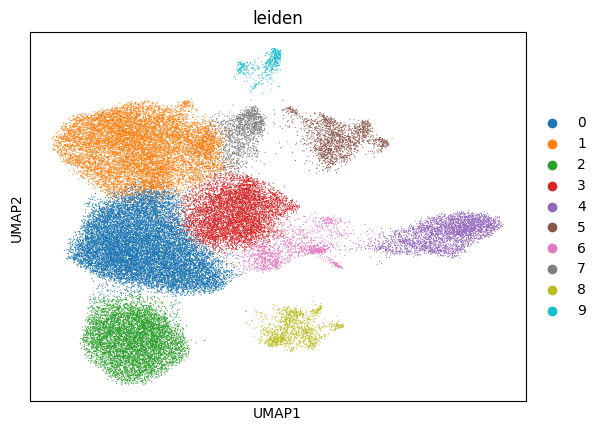

In [29]:
sc.pp.neighbors(adata_emb, n_neighbors = best_n_neighbors, n_pcs=best_npcs)
sc.tl.leiden(adata_emb, resolution=best_resolution)
nmi_score = normalized_mutual_info_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")
sc.tl.umap(adata_emb)
sc.pl.umap(adata_emb, color=['leiden'])

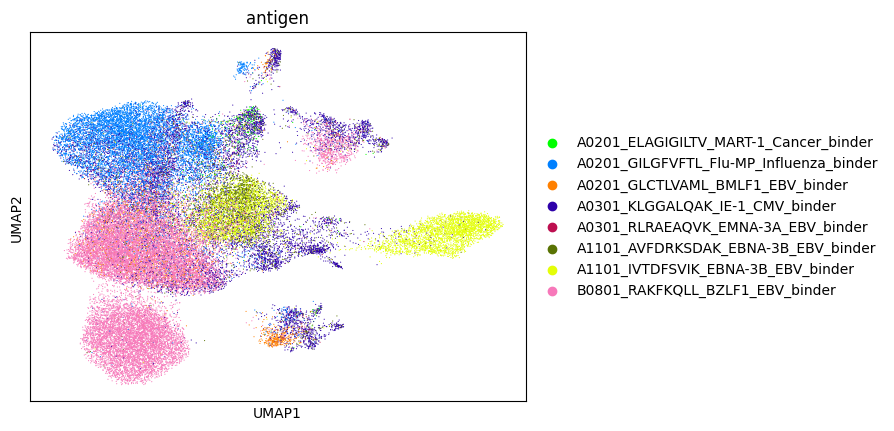

In [30]:
antigen_colors = {'A0201_ELAGIGILTV_MART-1_Cancer_binder': (0.0, 1.0, 0.0),
 'A0201_FLYALALLL_LMP2A_EBV_binder': (1.0, 0.0, 1.0),
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder': (0.0, 0.5, 1.0),
 'A0201_GLCTLVAML_BMLF1_EBV_binder': (1.0, 0.5, 0.0),
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder': (0.5, 0.75, 0.5),
 'A0301_KLGGALQAK_IE-1_CMV_binder': (0.1793537164011899,
  0.0033355078444660125,
  0.6620747897259032),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.73968214343272,
  0.05891730149257346,
  0.3146809676494471),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (0.349066435944829,
  0.4503226204406996,
  0.013129173322001919),
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (0.8921739233639615,
  0.9978312313940568,
  0.032996100920834937),
 'B0801_FLRGRAYGL_EBNA-3A_EBV_binder': (0.0, 1.0, 1.0),
 'B0801_RAKFKQLL_BZLF1_EBV_binder': (0.9677051631643115,
  0.47190225320587564,
  0.729773079807986),
 'unknown': (0.71, 0.71, 0.71)}
sc.pl.umap(
    adata_emb, 
    color=['antigen'], 
    palette=antigen_colors
)

In [31]:
# adata_emb.obs['antigen_color'] = [antigen_colors[x] for x in adata_emb.obs['antigen'].values]
# adata_emb.obs

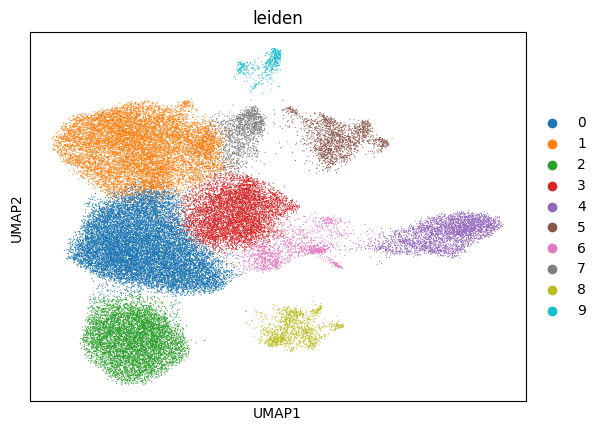

In [32]:
sc.pl.umap(adata_emb, color=['leiden'])

In [33]:
adata_emb.obs['antigen'].value_counts()

antigen
B0801_RAKFKQLL_BZLF1_EBV_binder            19240
A0201_GILGFVFTL_Flu-MP_Influenza_binder     8431
A0301_KLGGALQAK_IE-1_CMV_binder             8416
A1101_IVTDFSVIK_EBNA-3B_EBV_binder          5983
A1101_AVFDRKSDAK_EBNA-3B_EBV_binder         2681
A0201_GLCTLVAML_BMLF1_EBV_binder            1535
A0201_ELAGIGILTV_MART-1_Cancer_binder        237
A0301_RLRAEAQVK_EMNA-3A_EBV_binder           207
Name: count, dtype: int64

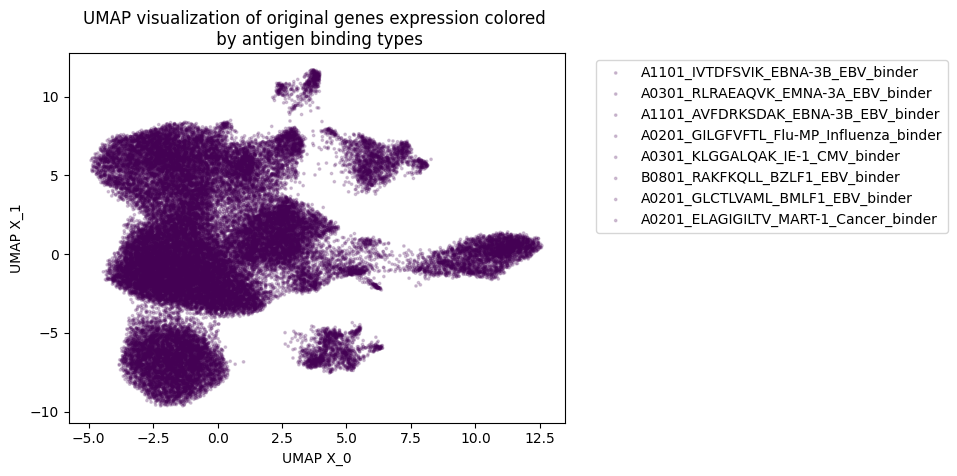

In [34]:
uniq = list(set(adata_emb.obs['antigen'].values))
alpha = 0.2

for i in range(len(uniq)):
    indx = adata_emb.obs['antigen'] == uniq[i]
    plt.scatter(adata_emb.obsm['X_umap'][list(indx),0], adata_emb.obsm['X_umap'][list(indx),1], s=3, c=adata_emb.obs['antigen'].astype('category').cat.codes.values[indx],label=uniq[i], alpha=alpha)

plt.xlabel('UMAP X_0')
plt.ylabel('UMAP X_1')
plt.title('UMAP visualization of original genes expression colored \n by antigen binding types')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0))
plt.show()

In [35]:
adata_emb.obs

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix,leiden
barcode,,,,,,,,,,,,,,,,,,,,,
AGGGTGAGTATTACCG-18,TRAV19,TRBV20-1,None,TRBD2,TRAJ40,TRBJ2-3,TRAC,TRBC2,CALSEASGTYKYIF,CSAPSGEGRDTQYF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,0,5478.0,3.738622,1830,0.058050,0,8
CTGCGGATCGACAGCC-31,TRAV14DV4,TRBV4-3,None,TRBD1,TRAJ28,TRBJ1-2,TRAC,TRBC1,CAMREPYSGAGSYQLTF,CASSQDRQGISIGYTF,...,1.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,6,2995.0,3.476397,1527,0.064775,5,0
GAGCAGAAGCGTGAGT-37,TRAV36DV7,TRBV9,None,TRBD1,TRAJ54,TRBJ1-1,TRAC,TRBC1,CAHLQGAQKLVF,CASSEGDRVTEAFF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,10,3915.0,3.592732,1624,0.028097,9,3
TGAAAGATCGAGAACG-32,TRAV16,TRBV29-1,None,TRBD1,TRAJ53,TRBJ2-2,TRAC,TRBC2,CALSGGSNYKLTF,CSDRGGTGELFF,...,0.0,A0201_GILGFVFTL_Flu-MP_Influenza_binder,GILGFVFTL,12,8505.0,3.929674,2151,0.067372,11,7
CGATGTACAGTTCATG-28,TRAV16,TRBV11-2,None,TRBD1,TRAJ49,TRBJ1-2,TRAC,TRBC1,CAPGNQFYF,CASSWGGGSHYGYTF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,13,1827.0,3.261739,1015,0.121511,12,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCTTCGACAGAGTGTG-6,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159387,3141.0,3.497068,1761,0.087552,145450,4
TTCTCCTTCCACGACG-7,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159389,5594.0,3.747722,1915,0.055417,145452,4
TCAGCAATCCTGCAGG-5,TRAV8-4,TRBV6-6,None,TRBD2,TRAJ10,TRBJ2-3,TRAC,TRBC2,CAVFTGGGNKLTF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159401,2433.0,3.386142,1441,0.090834,145463,4


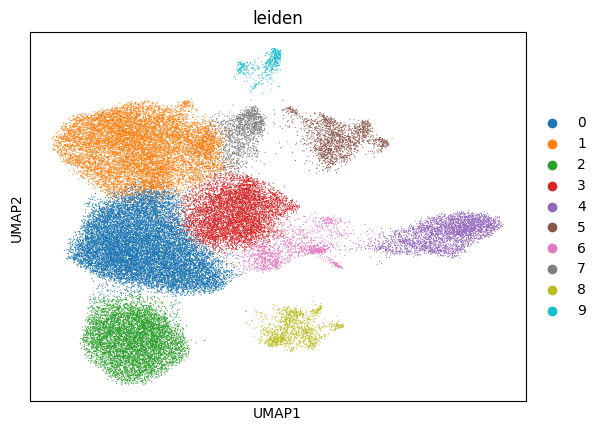

In [36]:
sc.pl.umap(adata_emb, color=['leiden'])

In [37]:
# sc.pl.umap(adata_emb, color=['IR_VDJ_1_junction_aa'])

In [38]:
# data_10X_dat[['cdr3b','Peptide_sequence']].groupby('cdr3b').value_counts().sort_values(ascending=False)

In [39]:
# data_10X_dat[data_10X_dat.cdr3b == "CASSLGFPNQPQHF"]        

In [40]:
# data_10X_dat[data_10X_dat.Peptide_sequence == "TTDPSFLGRY"].groupby('cdr3b')[['cdr3b','Peptide_sequence']].value_counts().sort_values(ascending=False)        

In [41]:
# data_10X_dat[data_10X_dat.Peptide_sequence == "LTDEMIAQY"].groupby('cdr3b')[['cdr3b','Peptide_sequence']].value_counts()        

In [42]:
from sklearn.metrics.cluster import normalized_mutual_info_score

In [43]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.4267984750040924


In [44]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.43288696715039915


In [45]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['cdr3_TRA'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.4286566001473371


In [46]:
ari_score = adjusted_rand_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

ARI Score: 0.37623075596411426


In [47]:
adjusted_rand_score(adata_emb.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)

0.194066888703984

In [48]:
sc.pl.umap(
    adata_gene, 
    color=['antigen'], 
    palette=antigen_colors
)

KeyError: "Could not find 'umap' or 'X_umap' in .obsm"